In [1]:
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
from scipy.spatial.distance import cdist
import numpy as np

In [7]:
# ============================================================
# DESCARGAR DW-NOMINATE SCORES — Voteview.com (API pública)
# Datos del 113° Congreso (2013-2015), mismo período del paper
# ============================================================

import pandas as pd # Added this line

print("⬇  Descargando DW-NOMINATE scores del 113° Congreso...")
print("   Fuente: voteview.com (datos públicos, sin API key)")

url_house = "https://voteview.com/static/data/out/members/H113_members.csv"
url_senate = "https://voteview.com/static/data/out/members/S113_members.csv"

try:
    df_house = pd.read_csv(url_house)
    df_senate = pd.read_csv(url_senate)

    # Combinar cámaras
    df_congress = pd.concat([df_house, df_senate], ignore_index=True)

    # Filtrar solo Demócratas y Republicanos (excluir independientes y vacantes)
    df_congress = df_congress[df_congress['party_code'].isin([100, 200])].copy()

    # Renombrar columnas para claridad
    df_congress['party'] = df_congress['party_code'].map({100: 'Democrat', 200: 'Republican'})
    df_congress['ideology'] = df_congress['nominate_dim1']  # Primera dimensión = liberal-conservador
    df_congress['chamber'] = df_congress['chamber'].map({'House': 'House', 'Senate': 'Senate'})

    # Limpiar
    df_congress = df_congress[['bioname', 'party', 'chamber', 'ideology', 'state_abbrev']].dropna()

    print(f"\n Datos descargados: {len(df_congress)} legisladores")
    print(f"   Demócratas: {(df_congress.party == 'Democrat').sum()}")
    print(f"   Republicanos: {(df_congress.party == 'Republican').sum()}")
    print(f"   Media Demócratas: {df_congress[df_congress.party=='Democrat'].ideology.mean():.3f}")
    print(f"   Media Republicanos: {df_congress[df_congress.party=='Republican'].ideology.mean():.3f}")
    print(f"   (Escala DW-NOMINATE: -1=liberal, +1=conservador)")
    REAL_DATA_AVAILABLE = True

except Exception as e:
    print(f"  No se pudo descargar: {e}")
    print("   → Usando datos DW-NOMINATE del 113° Congreso embebidos en el notebook")
    REAL_DATA_AVAILABLE = False

⬇  Descargando DW-NOMINATE scores del 113° Congreso...
   Fuente: voteview.com (datos públicos, sin API key)

 Datos descargados: 547 legisladores
   Demócratas: 261
   Republicanos: 286
   Media Demócratas: -0.372
   Media Republicanos: 0.480
   (Escala DW-NOMINATE: -1=liberal, +1=conservador)


In [8]:
# ── PARÁMETROS ────────────────────────────────────────────────────────────────
K       = 6        # vecinos más cercanos por nodo
C_DEM   = '#4A90D9'
C_REP   = '#E05A47'
C_BG    = '#10101A'

In [9]:
# Cada nodo se escala según cuántos legisladores tiene su estado en el dataset
# ══════════════════════════════════════════════════════════════════════════════
sc = df_congress['state_abbrev'].value_counts()
df_congress = df_congress.copy()
df_congress['node_size'] = df_congress['state_abbrev'].map(sc)
s0, s1 = df_congress['node_size'].min(), df_congress['node_size'].max()
df_congress['node_size_scaled'] = 55 + (df_congress['node_size'] - s0) / (s1 - s0) * 380
df_congress = df_congress.reset_index(drop=True)


In [10]:
# Cada legislador se conecta con sus K vecinos ideológicamente más cercanos
# La distancia entre dos nodos = diferencia absoluta en nominate_dim1

ideo_arr = df_congress['ideology'].values.reshape(-1, 1)
D = cdist(ideo_arr, ideo_arr, metric='euclidean')
np.fill_diagonal(D, np.inf)   # evitar self-loops

G = nx.Graph()
for i, row in df_congress.iterrows():
    G.add_node(i,
               label=row['bioname'].split(',')[0],   # solo apellido
               party=row['party'],
               ideology=row['ideology'],
               chamber=row['chamber'],
               state=row['state_abbrev'],
               size=float(row['node_size_scaled']))

for i in range(len(df_congress)):
    for j in np.argsort(D[i])[:K]:
        if not G.has_edge(i, j):
            G.add_edge(i, j, weight=float(1 / (D[i, j] + 1e-9)))

print(f"Red: {G.number_of_nodes()} nodos | {G.number_of_edges()} aristas")


Red: 547 nodos | 1908 aristas


In [11]:
# PASO 3 — TRES LAYOUTS
# ══════════════════════════════════════════════════════════════════════════════

# --- Fruchterman-Reingold ---
# Simula física: nodos similares se atraen, distintos se repelen
# Produce dos núcleos naturales separados por un vacío central
pos_fr = nx.spring_layout(G, weight='weight', seed=42, k=0.20, iterations=120)

# --- Sugiyama (aproximado con capas ideológicas) ---
# Ordena los nodos en columnas verticales de izquierda (-1) a derecha (+1)
# Permite leer la posición exacta de cada legislador en la escala
n_lay   = 16
iv      = np.array([G.nodes[n]['ideology'] for n in G.nodes])
edges_l = np.linspace(iv.min() - 0.01, iv.max() + 0.01, n_lay + 1)
layer_id = np.digitize(iv, edges_l) - 1
lcnt    = {}
for l in layer_id:
    lcnt[l] = lcnt.get(l, 0) + 1
cursor  = {l: 0 for l in range(n_lay)}
pos_sug = {}
for node, layer in zip(G.nodes, layer_id):
    x = (layer + 0.5) / n_lay * 2 - 1
    y = -0.5 + (cursor[layer] + 1) * (1.0 / (lcnt[layer] + 1))
    cursor[layer] += 1
    pos_sug[node] = (x, y)

# --- Davidson-Harel (aproximado con Kamada-Kawai) ---
# Minimiza el cruce de aristas preservando distancias reales de la red
# Revela puentes entre partidos y estructura global
pos_dh = nx.kamada_kawai_layout(G, weight='weight')


In [12]:
# PASO 4 — ATRIBUTOS VISUALES
# ══════════════════════════════════════════════════════════════════════════════
node_colors = [C_DEM if G.nodes[n]['party'] == 'Democrat' else C_REP for n in G.nodes]
node_sizes  = [G.nodes[n]['size'] for n in G.nodes]

# Aristas intra-partido vs inter-partido (puentes)
intra = [(u, v) for u, v in G.edges if G.nodes[u]['party'] == G.nodes[v]['party']]
inter = [(u, v) for u, v in G.edges if G.nodes[u]['party'] != G.nodes[v]['party']]

# Etiquetas solo para los más extremos ideológicamente
extreme = {n: G.nodes[n]['label'] for n in G.nodes if abs(G.nodes[n]['ideology']) > 0.72}

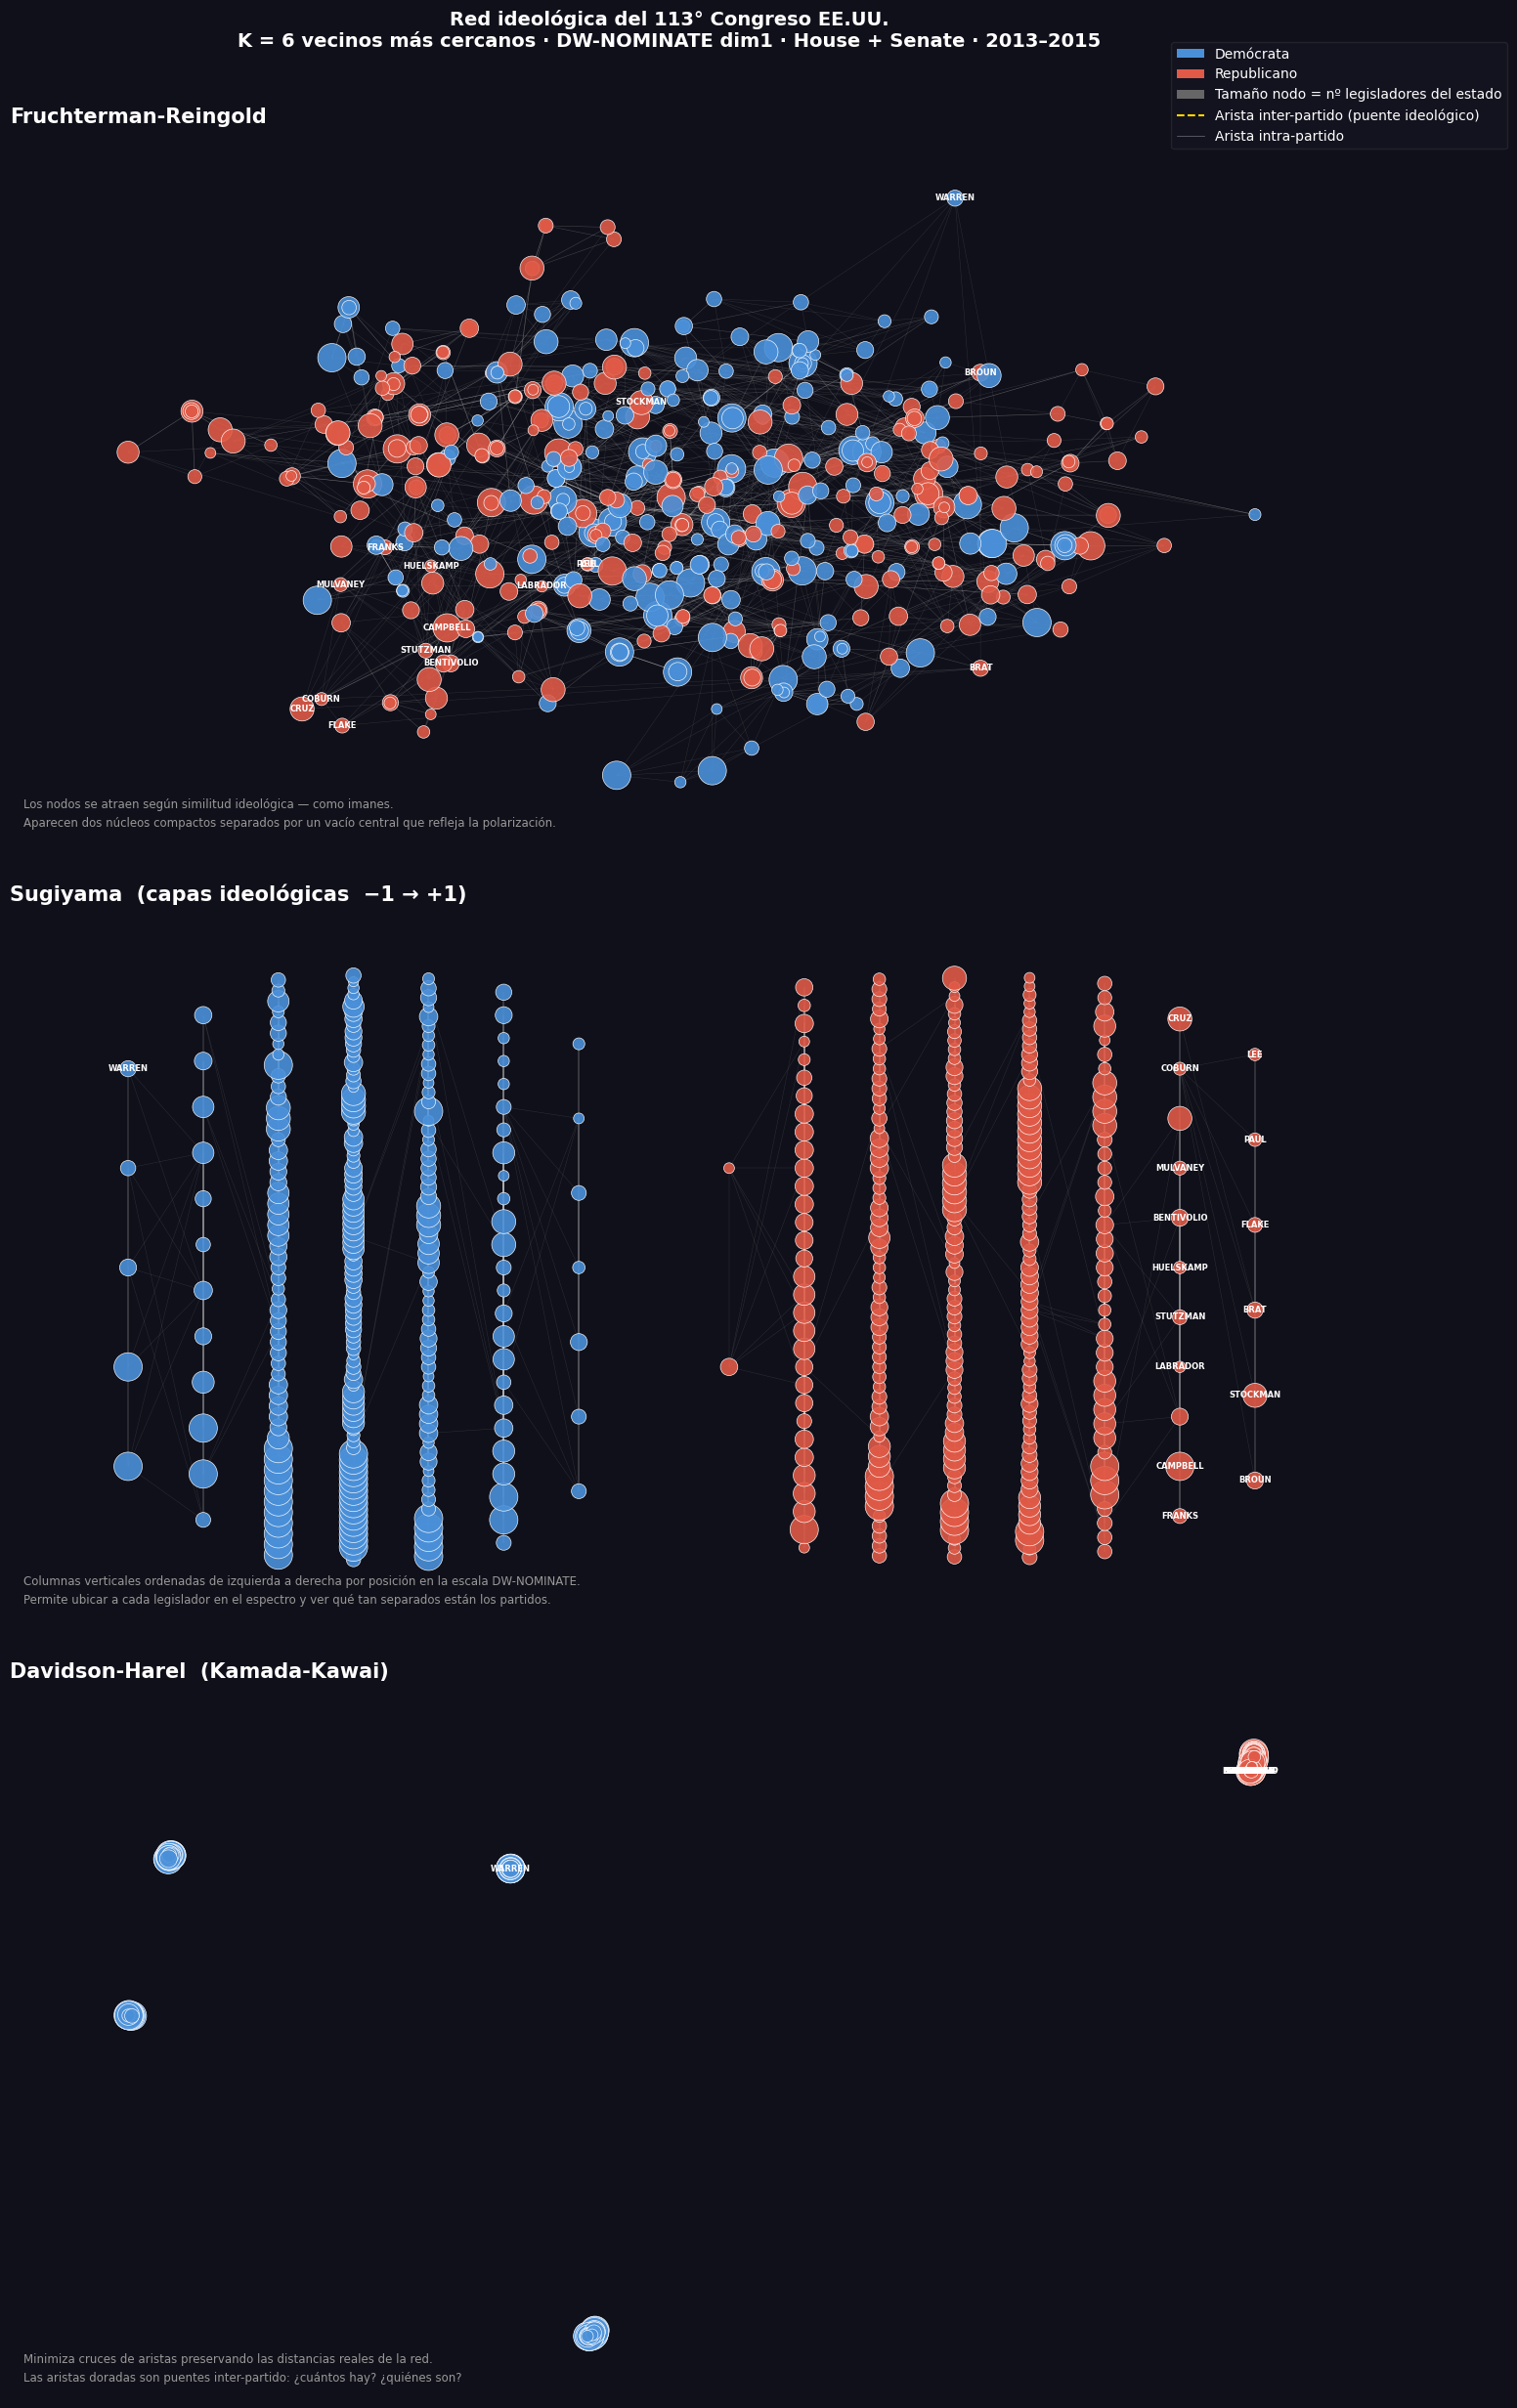

✓ Figura guardada como congress_network.png


In [13]:
# PASO 5 — FIGURA FINAL
# ══════════════════════════════════════════════════════════════════════════════
fig = plt.figure(figsize=(18, 26), facecolor=C_BG)
gs  = GridSpec(3, 1, figure=fig, hspace=0.10, top=0.93, bottom=0.04)

configs = [
    (pos_fr,
     'Fruchterman-Reingold',
     'Los nodos se atraen según similitud ideológica — como imanes.\n'
     'Aparecen dos núcleos compactos separados por un vacío central que refleja la polarización.'),

    (pos_sug,
     'Sugiyama  (capas ideológicas  −1 → +1)',
     'Columnas verticales ordenadas de izquierda a derecha por posición en la escala DW-NOMINATE.\n'
     'Permite ubicar a cada legislador en el espectro y ver qué tan separados están los partidos.'),

    (pos_dh,
     'Davidson-Harel  (Kamada-Kawai)',
     'Minimiza cruces de aristas preservando las distancias reales de la red.\n'
     'Las aristas doradas son puentes inter-partido: ¿cuántos hay? ¿quiénes son?'),
]

for idx, (pos, title, note) in enumerate(configs):
    ax = fig.add_subplot(gs[idx])
    ax.set_facecolor(C_BG)

    # Aristas intra (blanco tenue) e inter (dorado visible)
    nx.draw_networkx_edges(G, pos, edgelist=intra, ax=ax,
                           edge_color='white', width=0.35, alpha=0.12)
    nx.draw_networkx_edges(G, pos, edgelist=inter, ax=ax,
                           edge_color='#FFD700', width=1.1, alpha=0.60,
                           style='dashed')

    # Nodos
    nx.draw_networkx_nodes(G, pos, ax=ax,
                           node_color=node_colors, node_size=node_sizes,
                           alpha=0.90, linewidths=0.5, edgecolors='white')

    # Etiquetas de los más extremos
    nx.draw_networkx_labels(G, pos, labels=extreme, ax=ax,
                            font_size=6.0, font_color='white', font_weight='bold')

    ax.set_title(title, color='white', fontsize=15, fontweight='bold',
                 loc='left', pad=10)
    ax.text(0.01, 0.02, note, transform=ax.transAxes,
            color='#999999', fontsize=8.5, va='bottom', linespacing=1.6)
    ax.axis('off')

# Leyenda compartida
leg = [
    mpatches.Patch(facecolor=C_DEM,  label='Demócrata'),
    mpatches.Patch(facecolor=C_REP,  label='Republicano'),
    mpatches.Patch(facecolor='#666', label='Tamaño nodo = nº legisladores del estado'),
    plt.Line2D([0],[0], color='#FFD700', lw=1.5, linestyle='--', label='Arista inter-partido (puente ideológico)'),
    plt.Line2D([0],[0], color='white',   lw=0.5, alpha=0.4,      label='Arista intra-partido'),
]
fig.legend(handles=leg, loc='upper right', fontsize=10,
           framealpha=0.25, labelcolor='white',
           facecolor='#1C1C2E', edgecolor='#555',
           bbox_to_anchor=(0.98, 0.97))

fig.suptitle(
    'Red ideológica del 113° Congreso EE.UU.\n'
    f'K = {K} vecinos más cercanos · DW-NOMINATE dim1 · House + Senate · 2013–2015',
    color='white', fontsize=14, fontweight='bold'
)

plt.savefig('congress_network.png', dpi=160, bbox_inches='tight', facecolor=C_BG)
plt.show()
print("✓ Figura guardada como congress_network.png")


═══════════════════════════════════════════════════════
  ÍNDICE DE POLARIZACIÓN — 113° Congreso EE.UU.
═══════════════════════════════════════════════════════
  Media Demócratas:       -0.372
  Media Republicanos:     +0.480
  Distancia entre medias: 0.852
  Cohen's d:              6.27  ← índice principal
  Zona de solapamiento:   25.0% de legisladores
───────────────────────────────────────────────────────
  → Polarización MUY ALTA (d > 2.0)
═══════════════════════════════════════════════════════


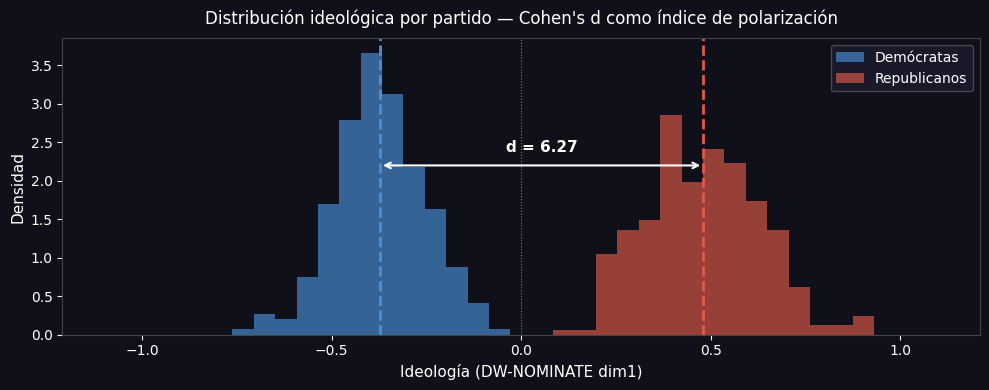

✓ Figura guardada como polarizacion_index.png


In [14]:
# BLOQUE 7 — ÍNDICE DE POLARIZACIÓN (Cohen's d)
#
# Mide cuántas desviaciones típicas separan las medias de los dos partidos.
# Es el índice más estándar para comparar dos distribuciones en un número.
#
# Interpretación:
#   d < 0.5  → separación pequeña
#   d ~ 0.8  → separación notable
#   d > 1.0  → separación fuerte
#   d > 2.0  → polarización muy alta
# ══════════════════════════════════════════════════════════════════════════════
dem_ideo = df_congress[df_congress.party == 'Democrat']['ideology']
rep_ideo = df_congress[df_congress.party == 'Republican']['ideology']

mean_dem  = dem_ideo.mean()
mean_rep  = rep_ideo.mean()
pooled_sd = np.sqrt((dem_ideo.std()**2 + rep_ideo.std()**2) / 2)
cohens_d  = (mean_rep - mean_dem) / pooled_sd

# Zona de solapamiento: legisladores entre el Q75 demócrata y el Q25 republicano
overlap_zone = (
    (df_congress.ideology > dem_ideo.quantile(0.75)) &
    (df_congress.ideology < rep_ideo.quantile(0.25))
)
pct_overlap = overlap_zone.mean() * 100

print("\n" + "═"*55)
print("  ÍNDICE DE POLARIZACIÓN — 113° Congreso EE.UU.")
print("═"*55)
print(f"  Media Demócratas:       {mean_dem:+.3f}")
print(f"  Media Republicanos:     {mean_rep:+.3f}")
print(f"  Distancia entre medias: {mean_rep - mean_dem:.3f}")
print(f"  Cohen's d:              {cohens_d:.2f}  ← índice principal")
print(f"  Zona de solapamiento:   {pct_overlap:.1f}% de legisladores")
print("─"*55)
if cohens_d > 2.0:
    print("  → Polarización MUY ALTA (d > 2.0)")
elif cohens_d > 1.0:
    print("  → Polarización ALTA (d > 1.0)")
elif cohens_d > 0.8:
    print("  → Polarización NOTABLE (d > 0.8)")
else:
    print("  → Polarización MODERADA (d < 0.8)")
print("═"*55)

# Gráfica: distribuciones superpuestas con anotación del d
fig2, ax2 = plt.subplots(figsize=(10, 4), facecolor=C_BG)
ax2.set_facecolor(C_BG)

bins = np.linspace(-1.1, 1.1, 40)
ax2.hist(dem_ideo, bins=bins, color=C_DEM, alpha=0.65, density=True, label='Demócratas')
ax2.hist(rep_ideo, bins=bins, color=C_REP, alpha=0.65, density=True, label='Republicanos')
ax2.axvline(mean_dem, color=C_DEM, lw=2, linestyle='--')
ax2.axvline(mean_rep, color=C_REP, lw=2, linestyle='--')
ax2.axvline(0, color='gray', lw=0.8, linestyle=':')

# Flecha con la distancia entre medias y el valor de d
ax2.annotate('', xy=(mean_rep, 2.2), xytext=(mean_dem, 2.2),
             arrowprops=dict(arrowstyle='<->', color='white', lw=1.5))
ax2.text((mean_dem + mean_rep) / 2, 2.38,
         f"d = {cohens_d:.2f}", ha='center', color='white', fontsize=11, fontweight='bold')

ax2.set_xlabel('Ideología (DW-NOMINATE dim1)', color='white', fontsize=11)
ax2.set_ylabel('Densidad', color='white', fontsize=11)
ax2.tick_params(colors='white')
for spine in ax2.spines.values():
    spine.set_edgecolor('#444')
ax2.legend(fontsize=10, labelcolor='white', facecolor='#1C1C2E', edgecolor='#555')
ax2.set_title("Distribución ideológica por partido — Cohen's d como índice de polarización",
              color='white', fontsize=12, pad=10)

plt.tight_layout()
plt.savefig('polarizacion_index.png', dpi=150, bbox_inches='tight', facecolor=C_BG)
plt.show()
print("✓ Figura guardada como polarizacion_index.png")


In [18]:
# BLOQUE 8 — PUENTES INTER-PARTIDO
#
# Un puente es un legislador que tiene al menos 1 vecino del partido contrario
# entre sus K vecinos más cercanos. Son los casos más interesantes porque
# muestran quién está en la frontera ideológica real de la red.
# ══════════════════════════════════════════════════════════════════════════════
bridge_rows = []

for node in G.nodes:
    neighbors   = list(G.neighbors(node))
    my_party    = G.nodes[node]['party']
    my_ideology = G.nodes[node]['ideology']
    my_name     = df_congress.loc[node, 'bioname']
    my_chamber  = G.nodes[node]['chamber']
    my_state    = G.nodes[node]['state']

    # Vecinos del partido contrario
    cross_neighbors  = [n for n in neighbors if G.nodes[n]['party'] != my_party]
    if len(cross_neighbors) == 0:
        continue

    cross_ideologies = [G.nodes[n]['ideology'] for n in cross_neighbors]
    cross_names      = [df_congress.loc[n, 'bioname'].split(',')[0] for n in cross_neighbors]

    bridge_rows.append({
        'Legislador':         my_name,
        'Partido':            my_party,
        'Cámara':             my_chamber,
        'Estado':             my_state,
        'Ideología':          round(my_ideology, 3),
        'Vecinos_cruzados':   len(cross_neighbors),
        'Media_ideo_cruzada': round(np.mean(cross_ideologies), 3),
        'Nombres_cruzados':   ', '.join(cross_names),
    })

df_bridges = pd.DataFrame(bridge_rows)

print(f"\n{'═'*55}")
print(f"  PUENTES INTER-PARTIDO  ({len(df_bridges)} legisladores)")
print(f"  Tienen ≥1 vecino del partido contrario entre sus {K} más cercanos")
print(f"{'═'*55}")

if not df_bridges.empty:
    df_bridges = df_bridges.sort_values(
        ['Vecinos_cruzados', 'Ideología'], ascending=[False, False]
    ).reset_index(drop=True)

    print(df_bridges[['Legislador','Partido','Ideología',
                      'Vecinos_cruzados','Nombres_cruzados']].to_string(index=False))
    print(f"{'═'*55}")

    # Guardar como CSV para exploración cómoda
    df_bridges.to_csv('puentes_interpartido.csv', index=False)
    print(" Tabla guardada como puentes_interpartido.csv")
else:
    print(f"  No se encontraron legisladores con vecinos del partido contrario entre sus {K} más cercanos.")
    print(f"  Esto indica una alta polarización en la red ideológica.")
    print(f"{'═'*55}")


═══════════════════════════════════════════════════════
  PUENTES INTER-PARTIDO  (0 legisladores)
  Tienen ≥1 vecino del partido contrario entre sus 6 más cercanos
═══════════════════════════════════════════════════════
  No se encontraron legisladores con vecinos del partido contrario entre sus 6 más cercanos.
  Esto indica una alta polarización en la red ideológica.
═══════════════════════════════════════════════════════
